In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

Загрузка данных

In [3]:
train = pd.read_csv('train.csv', header=None).values
train_val = pd.read_csv('etalon_for_train.csv', header=None).values
test = pd.read_csv('test.csv', header=None).values
test_val = pd.read_csv('etalon_for_test.csv', header=None).values

In [4]:
N_history = 4000
N_forecast = 1000
dt = 0.05   # Дискретность измерений 

Разделение выборки

In [5]:
X_train = train[:, :N_history]
Y_train = train_val[:, N_history:]

X_test = test[:, :N_history]
Y_test = test_val[:, N_history:]

In [5]:
X_train

array([[ 0.8108   ,  0.32107  , -0.011351 , ..., -1.0154   , -0.93949  ,
        -0.10387  ],
       [-0.155    , -0.082717 , -0.48375  , ..., -1.4642   , -0.80546  ,
        -0.77923  ],
       [ 0.10334  ,  1.2834   ,  0.41724  , ..., -0.98236  , -0.097924 ,
         0.3862   ],
       ...,
       [ 0.26183  ,  0.48747  , -0.082113 , ...,  0.28967  ,  0.9845   ,
         1.63     ],
       [ 0.061188 ,  1.1269   ,  0.98563  , ...,  0.15677  ,  0.0062021,
         0.16791  ],
       [ 0.52276  ,  0.74624  ,  1.696    , ...,  0.75488  , -1.5613   ,
        -0.33662  ]])

In [6]:
Y_train

array([[-0.36963 , -0.37757 , -0.38551 , ...,  0.091342,  0.091299,
         0.090164],
       [-0.41455 , -0.41521 , -0.41742 , ...,  0.50371 ,  0.504   ,
         0.50222 ],
       [-0.3221  , -0.31484 , -0.30393 , ...,  0.61183 ,  0.61644 ,
         0.61644 ],
       ...,
       [ 0.54228 ,  0.55249 ,  0.56451 , ...,  1.7396  ,  1.7275  ,
         1.7092  ],
       [ 0.14261 ,  0.15789 ,  0.17453 , ..., -0.38625 , -0.36972 ,
        -0.35555 ],
       [-0.58242 , -0.59693 , -0.60961 , ..., -0.89327 , -0.89398 ,
        -0.89181 ]])

Применяем фильтр Гаусса для плавного сглаживания

In [6]:
from scipy.ndimage import gaussian_filter1d

X_train_filter = gaussian_filter1d(X_train, sigma=2)
X_test_filter = gaussian_filter1d(X_test, sigma=2)

In [8]:
X_train_filter

array([[ 0.49285584,  0.47507528,  0.46092319, ..., -0.62551211,
        -0.59810608, -0.56869459],
       [-0.24469809, -0.27104418, -0.29597517, ..., -0.64240237,
        -0.76227446, -0.81713779],
       [ 0.56324829,  0.56222742,  0.54396377, ..., -0.49082131,
        -0.29863291, -0.17114597],
       ...,
       [ 0.2300111 ,  0.20927292,  0.18934783, ...,  0.7945993 ,
         0.94854158,  1.05099499],
       [ 0.55347732,  0.5543894 ,  0.54084542, ...,  0.28656335,
         0.21230449,  0.16914467],
       [ 0.7840097 ,  0.80663229,  0.83244455, ..., -0.43998383,
        -0.52041466, -0.56735497]])

In [7]:
scaler_x = StandardScaler()
X_train_scaled = scaler_x.fit_transform(X_train_filter)
X_test_scaled = scaler_x.transform(X_test_filter)

In [10]:
X_train_scaled

array([[ 0.89046299,  0.88071214,  0.87739225, ..., -1.11196776,
        -1.04405164, -0.97567452],
       [-0.42520581, -0.48611945, -0.54770409, ..., -1.14127008,
        -1.32209383, -1.38703733],
       [ 1.01603096,  1.04036794,  1.03374194, ..., -0.87829738,
        -0.53685178, -0.31742861],
       ...,
       [ 0.42159338,  0.39378333,  0.36606725, ...,  1.35173416,
         1.57541333,  1.70614596],
       [ 0.99860125,  1.02600931,  1.02787068, ...,  0.47036024,
         0.32849244,  0.2460117 ],
       [ 1.40983119,  1.48809825,  1.57689665, ..., -0.7901012 ,
        -0.91247031, -0.97345642]])

In [8]:
from sklearn.model_selection import train_test_split

X_train_final, X_val, Y_train_final, Y_val = train_test_split(
    X_train_scaled,   
    Y_train,      
    test_size=0.2,    
    random_state=42,
    shuffle=False 
)

Обучение модели

In [9]:
def compute_error_metrics(Y_pred, Y_true):
    error_matrix = Y_pred - Y_true
    mean_error = np.mean(error_matrix, axis=0)
    rms_error = np.sqrt(np.mean((error_matrix - mean_error)**2, axis=0))
    return mean_error, rms_error


def combined_score(mean_error, rms_error):
    return 0.5 * np.mean(np.abs(mean_error)) + 0.5 * np.mean(rms_error)

In [10]:
param_grid = {
    'hidden_layer_sizes': [
        (100, 50),
        (200, 100)
    ],
    'activation': ['relu', 'tanh'],
    'alpha': [0.001, 0.01],
    'learning_rate_init': [0.001, 0.002]
}

In [11]:
from itertools import product
import time

def train_final_model(X_train, Y_train, X_test, Y_test, params):
    best_score = np.inf
    best_params = None
    best_model = None
    all_results = []

    keys = list(param_grid.keys())
    values = [param_grid[k] for k in keys]
    combinations = list(product(*values))

    total = len(combinations)
    print(f"Всего комбинаций для проверки: {total}")

    for idx, combo in enumerate(combinations):
        params = dict(zip(keys, combo))
        start_time = time.time()
    
        model = MLPRegressor(
            hidden_layer_sizes=params['hidden_layer_sizes'],
            activation=params['activation'],
            alpha=params['alpha'],
            learning_rate_init=params['learning_rate_init'],
            max_iter=500,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=20,
            random_state=42,
            verbose=True
        )

        print("\nОбучение модели...")
        model.fit(X_train, Y_train)

        print("\nОценка")
        Y_pred = model.predict(X_test)

        error_matrix = Y_pred - Y_test
        mean_error = np.mean(error_matrix, axis=0)
        rms_error = np.sqrt(np.mean((error_matrix - mean_error)**2, axis=0))
    
        print(f"\nМетрики:")
        print(f"Mean Error: {np.mean(np.abs(mean_error)):.3f}")
        print(f"RMS Error: {np.mean(rms_error):.3f}")
        print(f"Combined Score: {0.5*np.mean(np.abs(mean_error)) + 0.5*np.mean(rms_error):.3f}")

    return model

In [12]:
model = train_final_model(X_train_final, Y_train_final, X_val, Y_val, param_grid)

Всего комбинаций для проверки: 16

Обучение модели...
Iteration 1, loss = 0.15788475
Validation score: -0.075673
Iteration 2, loss = 0.14459428
Validation score: -0.049252
Iteration 3, loss = 0.14154785
Validation score: -0.032113
Iteration 4, loss = 0.14012315
Validation score: -0.024718
Iteration 5, loss = 0.13916061
Validation score: -0.023327
Iteration 6, loss = 0.13812675
Validation score: -0.023352
Iteration 7, loss = 0.13682125
Validation score: -0.025926
Iteration 8, loss = 0.13489069
Validation score: -0.029153
Iteration 9, loss = 0.13228115
Validation score: -0.035345
Iteration 10, loss = 0.12898847
Validation score: -0.042367
Iteration 11, loss = 0.12481325
Validation score: -0.051823
Iteration 12, loss = 0.12009348
Validation score: -0.064695
Iteration 13, loss = 0.11494415
Validation score: -0.076062
Iteration 14, loss = 0.10938581
Validation score: -0.088237
Iteration 15, loss = 0.10377026
Validation score: -0.105997
Iteration 16, loss = 0.09811286
Validation score: -0.11

Прогноз

In [13]:
Y_pred = model.predict(X_test_scaled)

In [16]:
mean_error, rms_error = compute_error_metrics(Y_pred, Y_test)
print(mean_error)
print(rms_error)

[-7.62974813e-02  3.71283501e-02 -2.55328456e-02 -5.40578246e-02
  1.16070420e-02 -8.61307361e-03 -2.49639144e-02 -1.94972648e-02
 -2.13200902e-02  3.45558567e-03  7.30660710e-03  9.97177938e-03
 -2.26985164e-02 -5.98419516e-03  1.09999562e-02 -2.44623126e-02
 -1.62104091e-02 -1.57625992e-02 -3.98530245e-02 -3.01766638e-02
  2.84859603e-02 -8.66414717e-03 -2.99840252e-03 -9.82233168e-03
 -4.75794267e-02 -3.45074297e-02 -5.90055088e-03 -1.69603698e-02
 -6.00020879e-02 -3.07675198e-02 -2.11177872e-02 -2.69823444e-03
 -3.67198965e-02  2.17541592e-02  1.68438348e-02 -2.29917593e-02
  5.45365603e-04 -1.99520619e-02 -5.07811106e-02 -9.78732999e-03
  4.18735901e-03  4.68439161e-02 -3.51098151e-02 -4.53165660e-02
  1.81535949e-02 -1.98066272e-02 -1.56019395e-02  4.35252812e-04
  1.17198839e-02 -8.12389547e-03 -2.32152975e-02  1.33013549e-02
 -2.11762101e-02 -1.68874733e-03  3.18558633e-02  2.05401317e-03
  1.37855134e-02  1.13181012e-02  3.71149163e-02 -5.30809215e-02
  2.73087734e-02 -5.33124

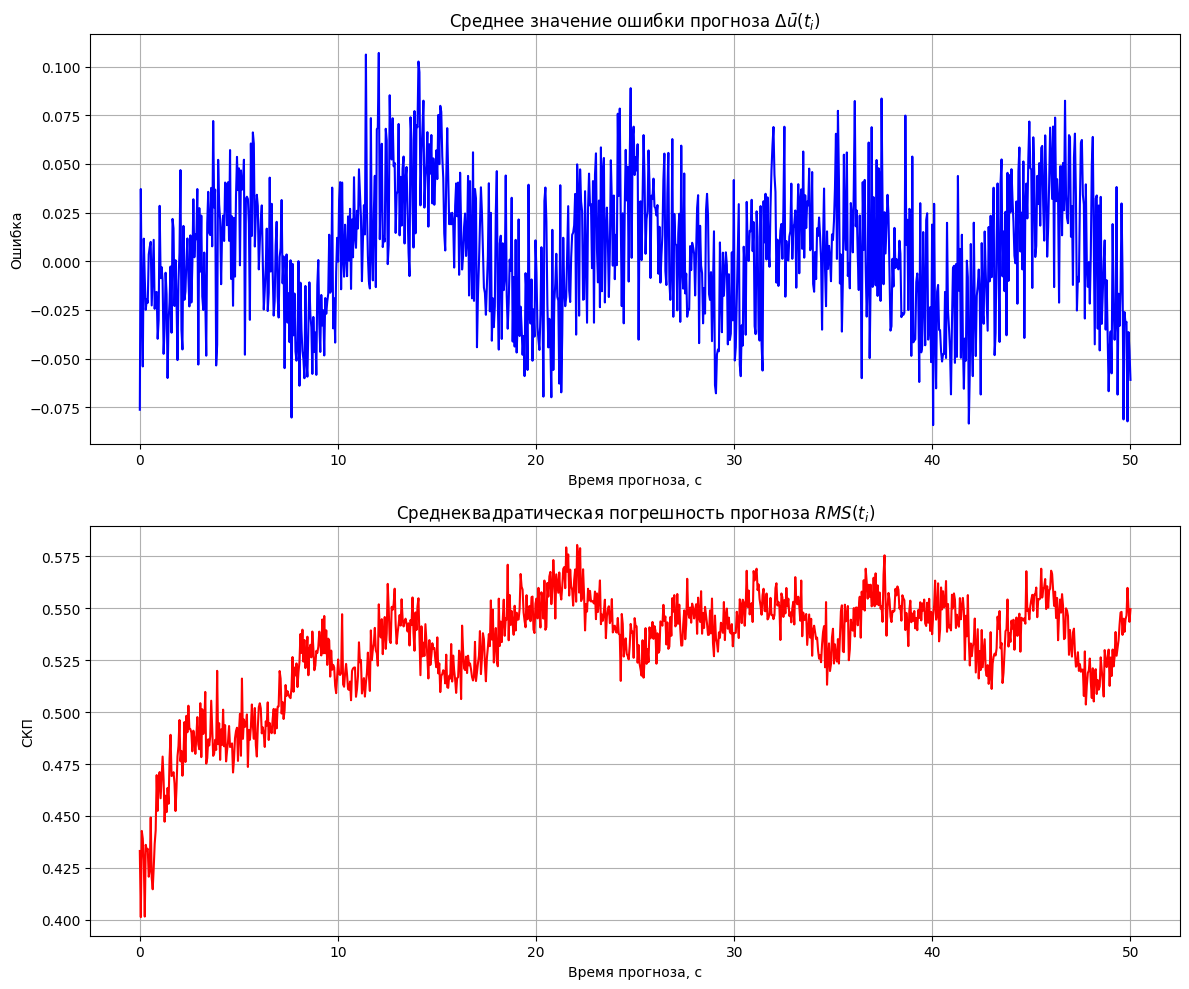

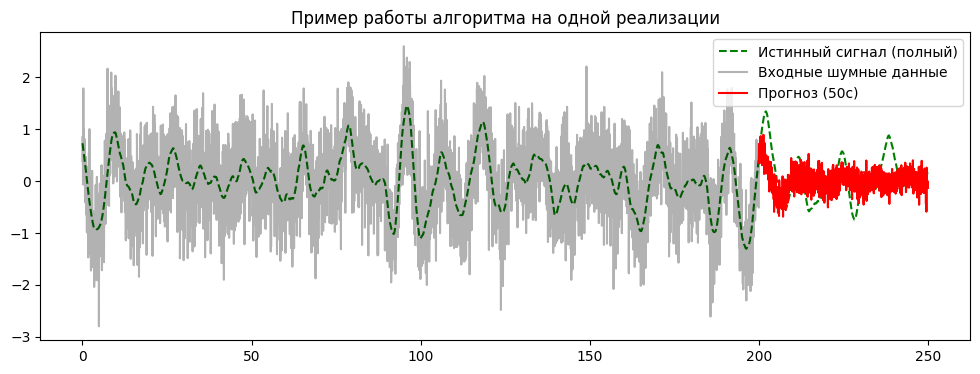

In [17]:
t_forecast = np.linspace(0, 50, N_forecast)

fig, ax = plt.subplots(2, 1, figsize=(12, 10))

ax[0].plot(t_forecast, mean_error, color='blue')
ax[0].set_title("Среднее значение ошибки прогноза $\Delta \\bar{u}(t_i)$")
ax[0].set_xlabel("Время прогноза, с")
ax[0].set_ylabel("Ошибка")
ax[0].grid(True)

ax[1].plot(t_forecast, rms_error, color='red')
ax[1].set_title("Среднеквадратическая погрешность прогноза $RMS(t_i)$")
ax[1].set_xlabel("Время прогноза, с")
ax[1].set_ylabel("СКП")
ax[1].grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(np.linspace(0, 250, 5000), test_val[0], 'g--', label='Истинный сигнал (полный)')
plt.plot(np.linspace(0, 200, 4000), test[0, :4000], 'k', alpha=0.3, label='Входные шумные данные')
plt.plot(np.linspace(200, 250, 1000), Y_pred[0], 'r', label='Прогноз (50с)')
plt.legend()
plt.title("Пример работы алгоритма на одной реализации")
plt.show()
